In [13]:

import cv2
import mediapipe as mp

mp_pose = mp.solutions.pose
# Initialize the Pose model
pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)
# Open the webcam
cap = cv2.VideoCapture("../../data/raw_videos/test_clear.mp4")

# Process the video frames
success, frame = cap.read()
if success:
    print(f"success: {success}, frame shape: {frame.shape}")
    # Convert the BGR image to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    print(f"converted successfully, frame_rgb shape: {frame_rgb.shape}")
else:
    print("Failed to read the video frame.")
# Process the frame with the Pose model
results = pose.process(frame_rgb)
# Extract the pose landmarks
if results.pose_landmarks:
    print("Pose landmarks detected:")
    RIGHT_WRIST_INDEX=mp_pose.PoseLandmark.RIGHT_WRIST
    right_wrist= results.pose_landmarks.landmark[RIGHT_WRIST_INDEX]
    print(f"Right wrist coordinates: x={right_wrist.x}, y={right_wrist.y}, z={right_wrist.z}")
    LEFT_WRIST_INDEX=mp_pose.PoseLandmark.LEFT_WRIST
    left_wrist= results.pose_landmarks.landmark[LEFT_WRIST_INDEX]
    print(f"Left wrist coordinates: x={left_wrist.x}, y={left_wrist.y}, z={left_wrist.z}")
    RIGHT_SHOULDER_INDEX=mp_pose.PoseLandmark.RIGHT_SHOULDER
    right_shoulder= results.pose_landmarks.landmark[RIGHT_SHOULDER_INDEX]
    print(f"Right shoulder coordinates: x={right_shoulder.x}, y={right_shoulder.y}, z={right_shoulder.z}")
    RIGHT_ELBOW_INDEX = mp_pose.PoseLandmark.RIGHT_ELBOW
    right_elbow= results.pose_landmarks.landmark[RIGHT_ELBOW_INDEX]
    print(f"Right elbow coordinates: x={right_elbow.x}, y={right_elbow.y}, z={right_elbow.z}")
else:
    print("No pose landmarks detected.")
cap.release()
pose.close()



success: True, frame shape: (1920, 1080, 3)
converted successfully, frame_rgb shape: (1920, 1080, 3)
Pose landmarks detected:
Right wrist coordinates: x=0.4796363115310669, y=0.47480764985084534, z=-0.031328003853559494
Left wrist coordinates: x=0.7282787561416626, y=0.46186622977256775, z=-0.6661546230316162
Right shoulder coordinates: x=0.5872863531112671, y=0.41509369015693665, z=0.19643494486808777
Right elbow coordinates: x=0.5815876722335815, y=0.4832611083984375, z=0.22908450663089752


I0000 00:00:1775319936.542403   80554 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775319936.549393  107907 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1775319936.621917  107892 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775319936.645491  107900 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [15]:

import cv2
import mediapipe as mp

mp_pose = mp.solutions.pose
# Initialize the Pose model
pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)
# Open the webcam
cap = cv2.VideoCapture("../../data/raw_videos/test_clear.mp4")

right_wrist_x=[]
right_wrist_y=[]
right_wrist_z=[]
# Process the video frames
while True:
    success, frame = cap.read()

    if not success:
        print("Failed to read the video frame.")
        break
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # Process the frame with the Pose model
    results = pose.process(frame_rgb)
    # Extract the pose landmarks
    if results.pose_landmarks:
        print("Pose landmarks detected:")
        RIGHT_WRIST_INDEX=mp_pose.PoseLandmark.RIGHT_WRIST
        right_wrist= results.pose_landmarks.landmark[RIGHT_WRIST_INDEX]
        right_wrist_x.append(right_wrist.x)
        right_wrist_y.append(right_wrist.y)
        right_wrist_z.append(right_wrist.z)

    else:
        print("No pose landmarks detected.")
for i in range(len(right_wrist_x)):
    print(f"Frame {i}: Right wrist coordinates: x={right_wrist_x[i]}, y={right_wrist_y[i]}, z={right_wrist_z[i]}")
cap.release()
pose.close()



I0000 00:00:1775320506.093618   80554 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775320506.104188  121373 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1775320506.186736  121358 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775320506.204983  121367 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:
Pose landmarks detected:


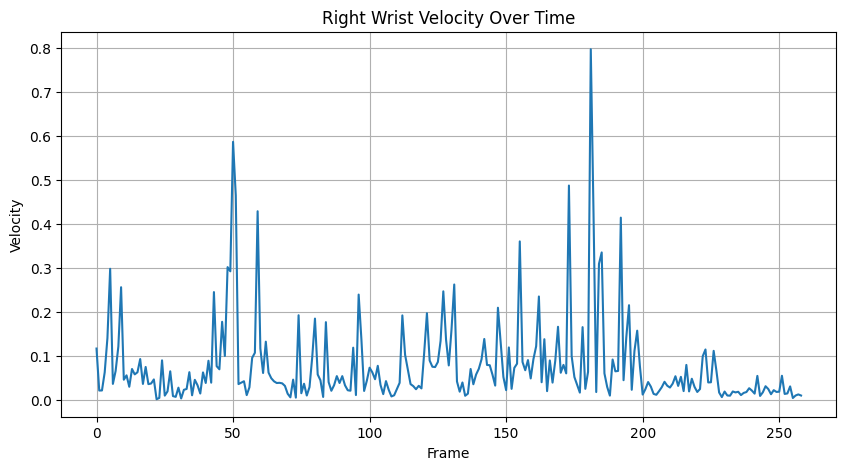

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import math

velocities = []
for i in range(1, len(right_wrist_x)):
    dx = right_wrist_x[i] - right_wrist_x[i-1]
    dy = right_wrist_y[i] - right_wrist_y[i-1]
    dz = right_wrist_z[i] - right_wrist_z[i-1]
    velocity = math.sqrt(dx**2 + dy**2 + dz**2)
    velocities.append(velocity)
# Display the velocities
plt.figure(figsize = (10,5))
plt.plot(velocities)
plt.title('Right Wrist Velocity Over Time')
plt.xlabel('Frame')
plt.ylabel('Velocity')
plt.grid(True)
plt.show()






In [23]:
import csv

save_path = "../../data/right_wrist_coordinates.csv"

data_rows = zip(range(len(right_wrist_x)), right_wrist_x, right_wrist_y, right_wrist_z)

with open(save_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Frame', 'Right Wrist X', 'Right Wrist Y', 'Right Wrist Z'])
    writer.writerows(data_rows)
print(f"✅ Right wrist coordinates saved to {save_path}")

✅ Right wrist coordinates saved to ../../data/right_wrist_coordinates.csv
